In [137]:
# Data Handling
import pandas as pd
import numpy as np

# Text Preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK data (run once)
nltk.download('stopwords')

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models (3 required)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix

# Hyperparameter tuning (optional but good for marks)
from sklearn.model_selection import GridSearchCV

# Save Model
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [138]:
fake_df=pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')
true_df=pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')

In [139]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [140]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [141]:
fake_df.info()

fake_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15421 entries, 0 to 15420
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    15421 non-null  object
 1   text     15421 non-null  object
 2   subject  15421 non-null  object
 3   date     15421 non-null  object
dtypes: object(4)
memory usage: 482.0+ KB


,title,text,subject,date
count,15421,15421,15421,15421
unique,15414,15035,2,1558
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"February 16, 2016"
freq,3,376,9050,32


In [142]:
true_df.info()
true_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10183 entries, 0 to 10182
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    10183 non-null  object
 1   text     10183 non-null  object
 2   subject  10183 non-null  object
 3   date     10183 non-null  object
dtypes: object(4)
memory usage: 318.3+ KB


,title,text,subject,date
count,10183,10183,10183,10183
unique,10074,10132,1,647
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"November 9, 2016"
freq,14,8,10183,115


Add label Column

In [143]:
fake_df["label"] = 0
true_df["label"] = 1

In [144]:
data = pd.concat([fake_df, true_df], axis=0)

print(data.shape)

(25604, 5)


Shuffle the values

In [145]:
data = data.sample(frac=1).reset_index(drop=True)

In [146]:
data.head()

,title,text,subject,date,label
0,Federal Judge Blows Lid Off Trump’s Biggest C...,One of the arguments against the Affordable Ca...,News,"March 16, 2017",0
1,"Trump to meet with Chicago mayor, North Caroli...",(This version of the story corrects date in l...,politicsNews,"December 7, 2016",1
2,"Mike Pence Breaks Silence, Responds To Being ...",After suffering the massively humiliating expe...,News,"February 20, 2017",0
3,Trump In For TREMENDOUS Shock If He Thinks He...,Trump has been very clear for the last week or...,News,"October 24, 2016",0
4,"To beat Zika in Rio, WHO prescribes safe sex a...",GENEVA (Reuters) - People travelling to the Ol...,politicsNews,"May 12, 2016",1


Distribution of real and fake news

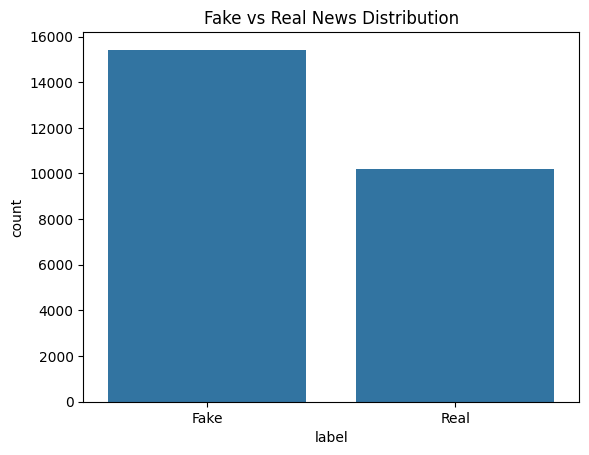

In [147]:
sns.countplot(x='label', data=data)
plt.title("Fake vs Real News Distribution")
plt.xticks([0,1], ['Fake','Real'])
plt.show()

Combining title and text as x

In [148]:
data["content"] = data["title"] + " " + data["text"]

X = data["content"]
y = data["label"]

wordcloud of fake news

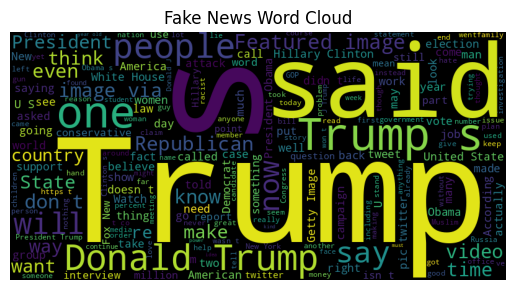

In [149]:
fake_words = ' '.join(data[data['label']==0]['content'])

wc = WordCloud(width=800, height=400).generate(fake_words)

plt.imshow(wc)
plt.axis('off')
plt.title("Fake News Word Cloud")
plt.show()

wordcloud of real news

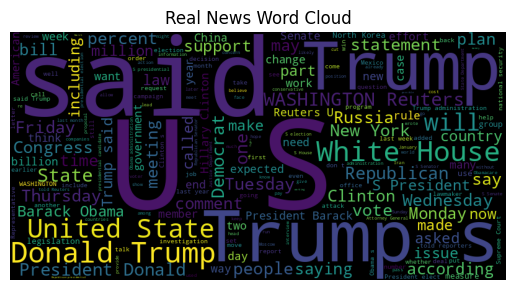

In [150]:
real_words = ' '.join(data[data['label']==1]['content'])

wc = WordCloud(width=800, height=400).generate(real_words)

plt.imshow(wc)
plt.axis('off')
plt.title("Real News Word Cloud")
plt.show()

length of sentences in fake and real news

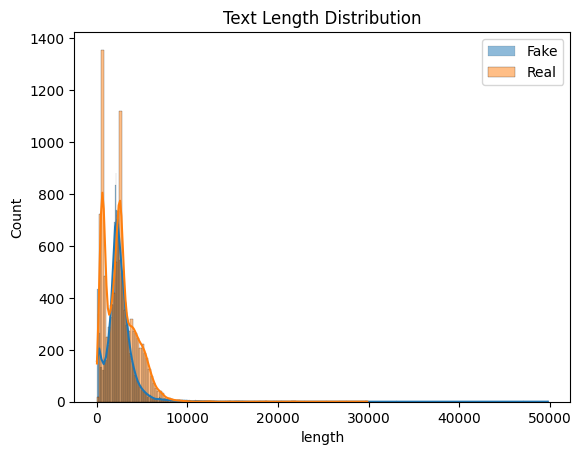

In [151]:
data['length'] = data['content'].apply(len)

sns.histplot(data[data['label']==0]['length'], label="Fake", kde=True)
sns.histplot(data[data['label']==1]['length'], label="Real", kde=True)

plt.legend()
plt.title("Text Length Distribution")
plt.show()

preprocessing

In [152]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W',' ',text)
    text = re.sub(r'\s+',' ',text)
    return text

data["content"] = data["content"].apply(clean_text)

data["content"].head()

,content
0,federal judge blows lid off trump s biggest c...
1,trump to meet with chicago mayor north carolin...
2,mike pence breaks silence responds to being m...
3,trump in for tremendous shock if he thinks he...
4,to beat zika in rio who prescribes safe sex an...


Drop unnessesary columns

In [153]:
data = data.drop(["title","text","subject","date"], axis=1)

convert everyting to lowercase

In [154]:
data["content"] = data["content"].str.lower()

Train test Split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    data["content"], y, test_size=0.2, random_state=42
)

In [156]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

Logistic regression

In [157]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

Naive Bayes

In [158]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

KNN

In [159]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

SVM

In [160]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

Evaluate models

In [161]:

def evaluate_model(name, y_test, pred):
    print(f"\n{name} Performance:")
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))
    print("MAE      :", mean_absolute_error(y_test, pred))
    print("MSE      :", mean_squared_error(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


# Predictions
pred1 = lr.predict(X_test)
pred2 = nb.predict(X_test)
pred3 = knn.predict(X_test)
pred4 = svm.predict(X_test)

# Evaluation
evaluate_model("Logistic Regression", y_test, pred1)
evaluate_model("Naive Bayes", y_test, pred2)
evaluate_model("KNN", y_test, pred3)
evaluate_model("SVM", y_test, pred4)


Logistic Regression Performance:
Accuracy : 0.9802772895918765
Precision: 0.9763104838709677
Recall   : 0.9728779507785033
F1 Score : 0.9745911949685535
MAE      : 0.019722710408123414
MSE      : 0.019722710408123414
Confusion Matrix:
 [[3083   47]
 [  54 1937]]

Naive Bayes Performance:
Accuracy : 0.9256004686584651
Precision: 0.9332615715823466
Recall   : 0.8709191361125063
F1 Score : 0.9010132501948558
MAE      : 0.07439953134153486
MSE      : 0.07439953134153486
Confusion Matrix:
 [[3006  124]
 [ 257 1734]]

KNN Performance:
Accuracy : 0.8269869166178481
Precision: 0.720558882235529
Recall   : 0.9065796082370668
F1 Score : 0.8029359430604982
MAE      : 0.17301308338215193
MSE      : 0.17301308338215193
Confusion Matrix:
 [[2430  700]
 [ 186 1805]]

SVM Performance:
Accuracy : 0.9925795743018941
Precision: 0.9894736842105263
Recall   : 0.9914615770969362
F1 Score : 0.9904666332162569
MAE      : 0.007420425698105838
MSE      : 0.007420425698105838
Confusion Matrix:
 [[3109   21]
 [ 

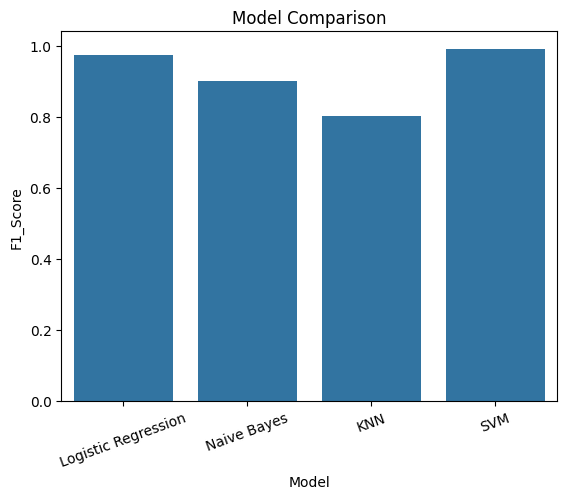

In [162]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Naive Bayes','KNN','SVM'],
    'F1_Score': [
        f1_score(y_test, pred1),
        f1_score(y_test, pred2),
        f1_score(y_test, pred3),
        f1_score(y_test, pred4)
    ]
})

sns.barplot(x='Model', y='F1_Score', data=results)
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

SVM model is giving best accuracy, precision, recall, f1 score

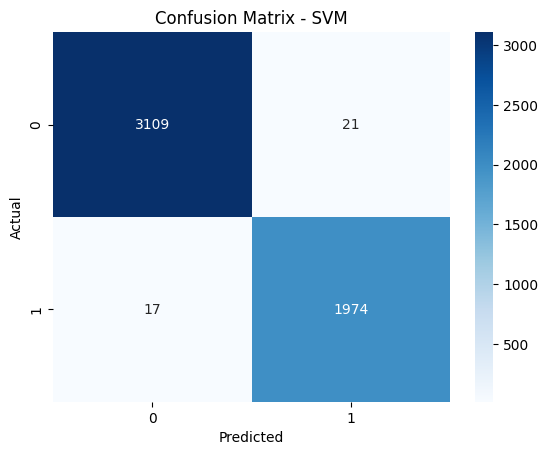

In [163]:

cm = confusion_matrix(y_test, pred4)  # SVM

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Save the model

In [165]:
pickle.dump(svm, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [166]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>